# **Prediksi Pembatalan Reservasi Hotel Menggunakan Model Klasifikasi Machine Learning: Studi Kasus Hotel Lonestar Oriental, Portugal | Part 3 - Machine Learning**

By: Daniel Berzelius H. dan Zahrah Mahfuzah - JCDSAHSR-004

In [2]:
!pip install country_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.1 MB/s eta 0:00:00


In [3]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.7 MB/s eta 0:00:00


In [4]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # untuk visualisasi geolokasi dan peta
import missingno as msno
import country_converter as coco # untuk mengkategorikan country sebagai sub kontinen

# Model Selection
# Preprocessing
import category_encoders as ce
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

# Train-test split & Model Selection
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV
)

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb

# Imbalanced Data Handling
from imblearn.over_sampling import (
    SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler, SMOTENC
)
from imblearn.under_sampling import (
    RandomUnderSampler, TomekLinks, EditedNearestNeighbours, NearMiss, OneSidedSelection
)
from imblearn.combine import SMOTEENN

# Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, make_scorer, precision_recall_curve
)

#++++++++++++++++++++++++++++++++++
# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
#++++++++++++++++++++++++++++++++++

from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF
# Statistik
from scipy import stats
from scipy.stats import (
    uniform, randint, shapiro, kstest, anderson, chi2_contingency, normaltest
)
# import display pictures JPG, JPEG, PNG
from IPython.display import display

Mounted at /content/drive


# 1. Komposisi data

Setelah data cleaning, feature engineering, dan EDA. Prediksi pembatalan hotel dilakukan dengan data yang benar benar bersih. Data dapat diakses melalui [link berikut](https://drive.google.com/drive/folders/1R2q2GPluMtHkEtftjWNX8tAbSWaoGLr0?hl=ID).

In [5]:
path = '/content/drive/MyDrive/Purwadhika/data_hotel_booking_demand_tuned.csv'
df_prep = pd.read_csv(path)

df_prep.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status_date,country_grouped,total_nights,total_people,weekend_ratio,booking_complexity,customer_reliability,lead_time_category,season,is_peak_season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,01/07/2015,Portugal,0,2.0,0.0,3,0.0,Long,Summer,1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,01/07/2015,Portugal,0,2.0,0.0,4,0.0,Very_Long,Summer,1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,02/07/2015,Northern Europe,1,1.0,0.0,0,0.0,Very_Short,Summer,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,02/07/2015,Northern Europe,1,1.0,0.0,0,0.0,Short,Summer,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,03/07/2015,Northern Europe,2,2.0,0.0,1,0.0,Short,Summer,1


In [6]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            

Dalam bagian machine learning ini, data yang diolah akan berjumlah `87396` yang tersebar dalam 37 kolom.

# 2. Machine Learning

###a. machine learning library

In [7]:
!pip install category_encoders

In [8]:
# Library

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# import missingno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold,train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import (
    SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler, SMOTENC
)
from imblearn.under_sampling import (
    RandomUnderSampler, TomekLinks, EditedNearestNeighbours, NearMiss, OneSidedSelection
)
from imblearn.combine import SMOTEENN
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
# from sklearn.metrics import roc_curve, roc_auc_score, plot_roc_curve

# Imbalance Dataset
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [9]:
# Import Additional Libraries for Preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from datetime import datetime

# Try import category encoders for binary encoding
try:
    import category_encoders as ce
    BINARY_ENCODING_AVAILABLE = True
    print("Category encoders available - Binary encoding enabled")
except ImportError:
    BINARY_ENCODING_AVAILABLE = False
    print("Category encoders not available - Using fallback encoding")

# Dataset info
print(f"Dataset shape: {df_prep.shape}")
print(f"Memory usage: {df_prep.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Category encoders available - Binary encoding enabled
Dataset shape: (87396, 37)
Memory usage: 73.28 MB


###b. imbalanced data

In [10]:
# CELL 3 : Target and Features Separation
target_column = 'is_canceled'

# Perbaikan: Hapus 'is_canceled' dan 'reservation_status' (Data Leakage)
# Jangan masukkan 'target_column' dalam tanda kutip di dalam .drop()
X = df_prep.drop(columns=[target_column, 'reservation_status'])
y = df_prep[target_column]

print(f"Target: {target_column}")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"Target proportion:")
print(y.value_counts(normalize=True).round(3)*100)

Target: is_canceled
Features shape: (87396, 35)
Target shape: (87396,)
Target distribution:
is_canceled
0    63371
1    24025
Name: count, dtype: int64
Target proportion:
is_canceled
0    72.5
1    27.5
Name: proportion, dtype: float64


Berdasarkan target `is_Canceled`, data tidak seimbang (_Imbalance_) sehingga perlu pendekatan untuk mengatasi ketidak seimbangan data ini menggunakan _Oversampling_ dan _Undersampling_.

Ketidakseimbangan data dapat menyebabkan model lebih bias terhadap kelas mayoritas. Untuk mengatasi hal ini, digunakan teknik oversampling, undersampling, dan hybrid sampling. Dalam proyek ini digunakan 11 teknik untuk mengatasi ketidakseimbangan data.

- **Variabel Oversampling**
  
  Menambah sampel kelas minoritas agar lebih seimbang.

  1. ROS: Melakukan duplikasi data secara acak sampel kelas minoritas.
  2. SMOTE: Membuat sampel sintetis dengan interpolasi data.
  3. BorderlineSMOTE: Menambah sampel di perbatasan antar kelas.
  4. ADASYN: Fokus pada sampel kelas minoritas yang sulit diprediksi.

- **Variabel Undersampling**
  
  Mengurangi sampel kelas mayoritas untuk keseimbangan.

  1. RandomUnderSampler: Menghapus sampel kelas mayoritas dari dataframe secara acak.
  2. TomekLinks: Menghapus sampel mayoritas yang memiliki kondisi dekat dengan minoritas. (Dibutuhkan untuk proyek ini untuk mendetailkan keputusan pembatalan ruang)
  3. ENN: Menghapus sampel mayoritas yang membingungkan model.
  4. NearMiss: Memilih sampel mayoritas yang paling dekat dengan minoritas.
  5. OSS: Gabungan TomekLinks dan ENN untuk seleksi sampel.

- **Variabel Hybrid Sampling**

  Menggabungkan oversampling dan undersampling.

  1. SMOTE + ENN: SMOTE untuk menambah, ENN untuk menghapus sampel mayoritas yang membingungkan.
  2. SMOTE + RUS: SMOTE untuk oversampling, RUS untuk mengurangi kelas mayoritas secara acak.

###c. encoding data

In [11]:
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)
print(f"Categorical features ({len(categorical_features)}):")

low_cardinality_features = []    # 2-10 unique values -> OneHot
med_cardinality_features = []    # 10-25 unique values -> Ordinal
high_cardinality_features = []   # >25 unique values -> Binary

cardinality_info = []
for col in categorical_features:
    unique_count = X[col].nunique()
    sample_values = X[col].unique()[:3].tolist()

    if unique_count <= 10:
        low_cardinality_features.append(col)
        category = "Low"
    elif unique_count <= 25:
        med_cardinality_features.append(col)
        category = "Medium"
    else:
        high_cardinality_features.append(col)
        category = "High"

    cardinality_info.append({
        'feature': col,
        'unique_count': unique_count,
        'category': category,
        'sample': sample_values
    })

    print(f"  {col}: {unique_count} unique ({category}) - {sample_values}")

print(f"ENCODING STRATEGY:")
print(f"  Low cardinality ({len(low_cardinality_features)}): OneHot Encoding")
print(f"  Medium cardinality ({len(med_cardinality_features)}): Ordinal Encoding")
print(f"  High cardinality ({len(high_cardinality_features)}): {'Binary' if BINARY_ENCODING_AVAILABLE else 'Ordinal'} Encoding")

Numerical features (24):
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_people', 'weekend_ratio', 'booking_complexity', 'customer_reliability', 'is_peak_season']
Categorical features (11):
  hotel: 2 unique (Low) - ['Resort Hotel', 'City Hotel']
  arrival_date_month: 12 unique (Medium) - ['July', 'August', 'September']
  meal: 5 unique (Low) - ['BB', 'FB', 'HB']
  market_segment: 8 unique (Low) - ['Direct', 'Corporate', 'Online TA']
  reserved_room_type: 10 unique (Low) - ['C', 'A', 'D']
  deposit_type: 3 unique (Low) - ['No Deposit', 'Refundable', 'Non Refund']
  customer_type: 4 unique (Low) - ['Transient', 'Contract', 'Transient-Party']
 

Dalam proses machine learning, diperlukan encoding dalam menangani data kategorik. Oleh sebab itu, klasifikasi encoding perlu dilakukan. Dalam proyek ini, klasifikasi encoding dibagi menjadi tiga:

- low cardinality (unique feature `kurang dari 10`)
- medium cardinality (unique feature `10<x<25`)
- high cardinalliyu (unique feature `lebih dari 25`)

penanganan setiap komponen dengan tingkat kardinalitas dilakukan berbeda:

- low cardinality akan diterapkan OneHot Encoding
- medium cardinality akan diterapkan Ordinal Encoding
- high cardinality akan diterapkan Binary Encoding

In [12]:
ordinal_mapping = [
    {
        'col': 'arrival_date_month',
        'mapping': {
            'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
            'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
        }
    },
    {
        'col': 'country_grouped',
        'mapping': {
            'Portugal': 1,
            'Western Europe': 2,
            'Northern Europe': 3,
            'Southern Europe': 4,
            'South America': 5,
            'Eastern Europe': 6,
            'Eastern Asia': 7,
            'Northern America': 8,
            'Western Asia': 9,
            'Australia and New Zealand': 10,
            'Northern Africa': 11,
            'Middle Africa': 12,
            'Southern Asia': 13,
            'South-eastern Asia': 14,
            'Central America': 15,
            'Eastern Africa': 16,
            'Western Africa': 17,
            'Southern Africa': 18,
            'Caribbean': 19,
            'Central Asia': 20,
            'Micronesia': 21,
            'Melanesia': 22,
            'Polynesia': 23,
            'Antarctica': 24,
            'Unknown': 0
        }
    }
]

In [13]:
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer([
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'),
     ['hotel','meal','market_segment', 'customer_type', 'reserved_room_type',
      'deposit_type', 'season', 'lead_time_category']), # <--- TAMBAHKAN INI

    ('ordinal', ce.OrdinalEncoder(mapping=ordinal_mapping),
     ['arrival_date_month', 'country_grouped']),

    ('binary', ce.BinaryEncoder(), ['reservation_status_date'])
], remainder='passthrough')

#3. Machine Learning Data Preparation

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, stratify=y)

menggunakan library scikit-learn untuk membagi dataset menjadi data latih (X_train, y_train) dan data uji (X_test, y_test). Parameter random_state=0 memastikan hasil pembagian selalu konsisten, sedangkan stratify=y menjaga agar proporsi kelas pada data latih dan data uji tetap sama seperti pada dataset asli.

In [15]:
X_train_backup = X_train.copy()

In [16]:
# Model akan belajar dari X_train (mengabaikan kategori asing nantinya)
X_train = transformer.fit_transform(X_train, y_train)

# Sekarang saat menemukan kata 'Other' di X_test, OHE akan diam saja dan memberinya nilai 0 di semua kolom
X_test = transformer.transform(X_test)

#4. Oversampling

###a. Random Oversampling

In [17]:
ros = RandomOverSampler(random_state=0)
X_train_over_ros, y_train_over_ros = ros.fit_resample(X_train, y_train)

In [18]:
print("Distribusi setelah oversampling RandomOverSampler:", y_train_over_ros.value_counts(normalize=True))
print("Jumlah data setelah oversampling RandomOverSampler:", X_train_over_ros.shape[0])

Distribusi setelah oversampling RandomOverSampler: is_canceled
1    0.5
0    0.5
Name: proportion, dtype: float64
Jumlah data setelah oversampling RandomOverSampler: 95056


Setelah oversampling menggunakan RandomOverSampler, distribusi kelas menjadi
seimbang (`0.5`& `0.5`). Jumlah total data setelah oversampling meningkat menjadi 95.056 sampel.

###b. SMOTE

In [19]:
smote = SMOTE(random_state=0)
X_train_over_smote, y_train_over_smote = smote.fit_resample(X_train, y_train)

In [20]:
print("Distribusi setelah oversampling SMOTE:", y_train_over_smote.value_counts(normalize=True))
print("Jumlah data setelah oversampling SMOTE:", X_train_over_smote.shape[0])

Distribusi setelah oversampling SMOTE: is_canceled
1    0.5
0    0.5
Name: proportion, dtype: float64
Jumlah data setelah oversampling SMOTE: 95056


Setelah oversampling menggunakan SMOTE, distribusi kelas menjadi
seimbang (`0.5`& `0.5`). Jumlah total data setelah oversampling meningkat menjadi 95.056 sampel.

###c. BORDERLINE SMOTE

In [21]:
Bsmote = BorderlineSMOTE(random_state=0)
X_train_over_Bsmote, y_train_over_Bsmote = Bsmote.fit_resample(X_train, y_train)

In [22]:
print("Distribusi setelah oversampling BorderlineSMOTE:", y_train_over_Bsmote.value_counts(normalize=True))
print("Jumlah data setelah oversampling BorderlineSMOTE:", X_train_over_Bsmote.shape[0])

Distribusi setelah oversampling BorderlineSMOTE: is_canceled
1    0.5
0    0.5
Name: proportion, dtype: float64
Jumlah data setelah oversampling BorderlineSMOTE: 95056


Setelah oversampling menggunakan Borderline SMOTE, distribusi kelas menjadi
seimbang (`0.5`& `0.5`). Jumlah total data setelah oversampling meningkat menjadi 95.056 sampel.

###d. ADASYN

In [23]:
adasyn = ADASYN(random_state=0)
X_train_over_adasyn, y_train_over_adasyn = adasyn.fit_resample(X_train, y_train)

In [24]:
print("Distribusi setelah oversampling ADASYN:", y_train_over_adasyn.value_counts(normalize=True))
print("Jumlah data setelah oversampling ADASYN:", X_train_over_adasyn.shape[0])

Distribusi setelah oversampling ADASYN: is_canceled
1    0.508404
0    0.491596
Name: proportion, dtype: float64
Jumlah data setelah oversampling ADASYN: 96681


Setelah oversampling menggunakan ADASYN, distribusi kelas menjadi
seimbang (`0.509`& `0.491`). Jumlah total data setelah oversampling meningkat menjadi 96.681 sampel.

#UNDERSAMPLING

###a. Random Undersampling

In [25]:
rus = RandomUnderSampler(random_state=0)
X_train_under_rus, y_train_under_rus = rus.fit_resample(X_train, y_train)

In [26]:
print("Distribusi setelah undersampling RandomUnderSampler:", y_train_under_rus.value_counts(normalize=True))
print("Jumlah data setelah undersampling RandomUnderSampler:", X_train_under_rus.shape[0])

Distribusi setelah undersampling RandomUnderSampler: is_canceled
0    0.5
1    0.5
Name: proportion, dtype: float64
Jumlah data setelah undersampling RandomUnderSampler: 36038


Setelah undersampling menggunakan RandomUnderSampler, distribusi kelas menjadi
seimbang (`0.5`& `0.5`). Jumlah total data setelah undersampling, data berkurang menjadi 36.038

###b. NearMiss

In [27]:
from imblearn.under_sampling import NearMiss

nearmiss = NearMiss()
X_train_under_nearmiss, y_train_under_nearmiss = nearmiss.fit_resample(X_train, y_train)

In [28]:
print("Distribusi setelah undersampling NearMiss:", y_train_under_nearmiss.value_counts(normalize=True))
print("Jumlah data setelah undersampling NearMiss:", X_train_under_nearmiss.shape[0])

Distribusi setelah undersampling NearMiss: is_canceled
0    0.5
1    0.5
Name: proportion, dtype: float64
Jumlah data setelah undersampling NearMiss: 36038


Setelah undersampling menggunakan metode NearMiss, distribusi kelas menjadi
seimbang (`0.5`& `0.5`). Jumlah total data setelah undersampling, data berkurang menjadi 36.038

###c. TomekLinks

In [29]:
from imblearn.under_sampling import TomekLinks

tomek = TomekLinks()
X_train_under_tomek, y_train_under_tomek = tomek.fit_resample(X_train, y_train)

In [30]:
print("Distribusi setelah undersampling TomekLinks:", y_train_under_tomek.value_counts(normalize=True))
print("Jumlah data setelah undersampling TomekLinks:", X_train_under_tomek.shape[0])

Distribusi setelah undersampling TomekLinks: is_canceled
0    0.7051
1    0.2949
Name: proportion, dtype: float64
Jumlah data setelah undersampling TomekLinks: 61102


Setelah undersampling menggunakan TomekLinks, distribusi kelas menjadi
seimbang (`0.71`& `0.29`). Jumlah total data setelah undersampling, data berkurang menjadi 61.102

###d. Edit Nearest Neighbor

In [31]:
from imblearn.under_sampling import EditedNearestNeighbours

enn = EditedNearestNeighbours()
X_train_under_enn, y_train_under_enn = enn.fit_resample(X_train, y_train)

In [32]:
print("Distribusi setelah undersampling EditedNearestNeighbours:", y_train_under_enn.value_counts(normalize=True))
print("Jumlah data setelah undersampling EditedNearestNeighbours:", X_train_under_enn.shape[0])

Distribusi setelah undersampling EditedNearestNeighbours: is_canceled
0    0.584318
1    0.415682
Name: proportion, dtype: float64
Jumlah data setelah undersampling EditedNearestNeighbours: 43348


Setelah undersampling menggunakan EditNearestNeighbor, distribusi kelas menjadi
seimbang (`0.58`& `0.42`). Jumlah total data setelah undersampling, data berkurang menjadi 43.348

###e. One Sided Selection

In [33]:
from imblearn.under_sampling import OneSidedSelection

oss = OneSidedSelection()
X_train_under_oss, y_train_under_oss = oss.fit_resample(X_train, y_train)

In [34]:
print("Distribusi setelah undersampling OneSidedSelection:", y_train_under_oss.value_counts(normalize=True))
print("Jumlah data setelah undersampling OneSidedSelection:", X_train_under_oss.shape[0])

Distribusi setelah undersampling OneSidedSelection: is_canceled
0    0.705167
1    0.294833
Name: proportion, dtype: float64
Jumlah data setelah undersampling OneSidedSelection: 61116


Setelah undersampling menggunakan OneSidedSelection, distribusi kelas menjadi
seimbang (`0.70`& `0.30`). Jumlah total data setelah undersampling, data berkurang menjadi 61.113

#HYBRID SAMPLING

###a. SMOTE + ENN

In [35]:
# Hybrid Sampling: SMOTE + ENN
smote_enn = SMOTEENN(random_state=0)
X_train_hybrid_smote_enn, y_train_hybrid_smote_enn = smote_enn.fit_resample(X_train_over_smote, y_train_over_smote)

In [36]:
print("Distribusi setelah hybrid sampling SMOTEENN:", y_train_hybrid_smote_enn.value_counts(normalize=True))
print("Jumlah data setelah hybrid sampling SMOTEENN:", X_train_hybrid_smote_enn.shape[0])

Distribusi setelah hybrid sampling SMOTEENN: is_canceled
1    0.609812
0    0.390188
Name: proportion, dtype: float64
Jumlah data setelah hybrid sampling SMOTEENN: 57867


Hybrid sampling dilakukan dengan menggabungkan Oversampling dan Undersampling. Setelah hybrid sampling menggunakan kombinasi antara SMOTE dan ENN, distribusi kelas menjadi
seimbang (`0.60`& `0.40`). Jumlah total data setelah hybrid sampling, data berkurang menjadi 57.867

###b. SMOTE + RUS

In [37]:
# Hybrid Sampling: SMOTE + RUS
undersampler = RandomUnderSampler(random_state=0)
X_train_hybrid_undersampler, y_train_hybrid_undersampler = undersampler.fit_resample(X_train_over_smote, y_train_over_smote)

In [38]:
print("Distribusi setelah hybrid sampling RandomUnderSampler:", y_train_hybrid_undersampler.value_counts(normalize=True))
print("Jumlah data setelah hybrid sampling RandomUnderSampler:", X_train_hybrid_undersampler.shape[0])

Distribusi setelah hybrid sampling RandomUnderSampler: is_canceled
0    0.5
1    0.5
Name: proportion, dtype: float64
Jumlah data setelah hybrid sampling RandomUnderSampler: 95056


Hybrid sampling dilakukan dengan menggabungkan Oversampling dan Undersampling. Setelah hybrid sampling menggunakan kombinasi antara SMOTE dan Random Under Sampling, distribusi kelas menjadi
seimbang (`0.5`& `0.5`). Jumlah total data setelah hybrid sampling, data bertambah menjadi 95.056

#DICTIONARY SAMPLING

In [39]:
# Data (Pastikan X_train, y_train sudah dideklarasikan sebelumnya)
sampling_methods = {
    "Random OverSampler": RandomOverSampler(random_state=0).fit_resample(X_train, y_train),
    "SMOTE": SMOTE(random_state=0).fit_resample(X_train, y_train),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=0).fit_resample(X_train, y_train),
    "ADASYN": ADASYN(random_state=0).fit_resample(X_train, y_train),
    "Random UnderSampler": RandomUnderSampler(random_state=0).fit_resample(X_train, y_train),
    "Tomek Links": TomekLinks().fit_resample(X_train, y_train),
    "Edited Nearest Neighbours": EditedNearestNeighbours().fit_resample(X_train, y_train),
    "NearMiss": NearMiss().fit_resample(X_train, y_train),
    "One Sided Selection": OneSidedSelection().fit_resample(X_train, y_train),
    "SMOTE + ENN": SMOTEENN(random_state=0).fit_resample(X_train, y_train),
    "SMOTE + RUS": RandomUnderSampler(random_state=0).fit_resample(SMOTE(random_state=0).fit_resample(X_train, y_train)[0],
                                                                    SMOTE(random_state=0).fit_resample(X_train, y_train)[1])
}

#MODEL LEARNING

In [40]:
dtree = DecisionTreeClassifier(random_state=0, max_depth=5)
rf = RandomForestClassifier(random_state=0)
lgbm = lgb.LGBMClassifier(verbose=-1)
xgboost = XGBClassifier()


models = {
    'Decision Tree': dtree,
    'Random Forest': rf,
    'Light GBM': lgbm,
    'Xgboost': xgboost
}

Karena dataframe memiliki mayoritas data-data kategorik, model-model Machine Learning yang digunakan adalah model yang aman untuk memproses data kategorik. Model yang digunakan adalah:
1. `decision tree`
2. `random forest`
3. `light GBM`
4. `XGBoost`

###a. Model Terbaik Tanpa Resampling

Sebelum melakukan Learning dengan metode resampling, model dijalankan terlebih dahulu untuk mengetahui gambaran umum dataframe.

In [41]:
def evaluate_models(models, X_train, y_train, X_test, y_test, description, all_results):
    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
        recall = recall_score(y_test, y_pred, average='binary', pos_label=1)
        f1 = f1_score(y_test, y_pred, average='binary', pos_label=1)

        results.append([name, acc, precision, recall, f1, description])

    df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Resampling Method'])

    # Tambahkan hasil evaluasi ke dalam list global
    all_results.append(df_results)

    # Ambil 4 model terbaik berdasarkan F1-score
    return df_results.nlargest(4, 'F1-score')

# List untuk menyimpan semua hasil evaluasi
all_results = []

# Evaluasi tanpa resampling
df_top_4 = evaluate_models(models, X_train, y_train, X_test, y_test, "Tanpa Resampling", all_results)

# Lihat Hasil
display(df_top_4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Resampling Method
3,Xgboost,0.864982,0.779138,0.710123,0.743031,Tanpa Resampling
1,Random Forest,0.865303,0.820733,0.652514,0.727020,Tanpa Resampling
2,Light GBM,0.855096,0.762380,0.686980,0.722719,Tanpa Resampling
0,Decision Tree,0.790562,0.630904,0.573760,0.600977,Tanpa Resampling


Berdasarkan hasil tanpa resampling, model paling baik dalam F1-Score menggunakan XGBoost. Namun dalam presisi, Model paling baik adalah Random Forest. Meskipun seperti itu, perbedaan `accuracy` antara `random forest` dengan `XGBoost` memiliki presentase yang sangat rendah, hanya 0.1%. Sedangkan dalam `precision`, model menggunakan Random forest menempati posisi pertama, diikuti dengan XGboost

###b. Model Terbaik Dengan Resampling

Setelah mendapatkan gambaran mengenai dataframe yang memiliki nilai F1-score dan precision yang tinggi serta cukup stabil oleh XGBoost. Model dengan resampling dijalankan.

In [42]:
def evaluate_models_resample(models, X_train, y_train, X_test, y_test, description, all_results):
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
        recall = recall_score(y_test, y_pred, average='binary', pos_label=1)
        f1 = f1_score(y_test, y_pred, average='binary', pos_label=1)

        results.append([name, acc, precision, recall, f1, description])

    df_results = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Resampling Method'])

    # Ambil 1 model terbaik berdasarkan F1-score
    top_1 = df_results.nlargest(1, 'F1-score')

    # Tambahkan hasil evaluasi ke dalam list global
    all_results.append(top_1)

    return df_results

# List untuk menyimpan semua hasil evaluasi
all_results = []

# Evaluasi setiap metode resampling
for method, (X_resampled, y_resampled) in sampling_methods.items():
    evaluate_models_resample(models, X_resampled, y_resampled, X_test, y_test, method, all_results)

# Gabungkan semua hasil evaluasi menjadi satu DataFrame
df_all_results = pd.concat(all_results, ignore_index=True)

# Ambil 3 model terbaik berdasarkan F1-scoresecara keseluruhan
top_3_overall = df_all_results.nlargest(3, 'F1-score')

# DataFrame hasil akhir
df_all_results

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Model,Accuracy,Precision,Recall,F1-score,Resampling Method
0,Xgboost,0.846950,0.672320,0.864635,0.756446,Random OverSampler
1,Random Forest,0.880178,0.851015,0.683816,0.758309,SMOTE
2,Random Forest,0.878942,0.850323,0.679154,0.755161,BorderlineSMOTE
3,Random Forest,0.880635,0.852782,0.683816,0.759009,ADASYN
4,Random Forest,0.833860,0.650418,0.855311,0.738924,Random UnderSampler
5,Xgboost,0.869559,0.767548,0.753746,0.760585,Tomek Links
6,Xgboost,0.810563,0.607435,0.878788,0.718340,Edited Nearest Neighbours
7,Xgboost,0.742414,0.519420,0.841658,0.642394,NearMiss
8,Xgboost,0.871573,0.772572,0.755078,0.763725,One Sided Selection
9,Xgboost,0.813813,0.622627,0.819181,0.707506,SMOTE + ENN


Dari model tanpa resampling dan model dengan resampling, diketahui bahwa nilai F1-score memiliki kenaikan pada model dengan resampling, namun tidak signifikan, nilai hanya naik 1%. Berdasarkan u

1. XGBoost+ Random OverSampler
2. Random Forest + SMOTE
3. Random Forest + BonderlineSMOTE
4. Random Forest + ADASYN
5. Random Forest + Random UnderSampler
6. XGBoost + Tomek Links
7. XGBoost + ENN
8. XGBoost + NearMiss
9. Xgboost + One Sided Selection
10. XGBoost + SMOTE + ENN
11. XGBoost + SMOET + RUS

Untuk proses kepastian lebih lanjut model dan resampling yang mana yang akan digunakan, maka di lakukan Cross-Validation untuk melihat konsistensinya pada skor F1-scorenya.

###c. Cross Validation Resampling

In [43]:
# === Cross-Validation untuk Semua Model di df_all_results ===
cv_results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for _, row in df_all_results.iterrows():
    model_name = row['Model']

    # Ambil model yang sesuai dari dictionary models
    model = models[model_name]

    # Lakukan cross-validation dengan multiple scoring
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'precision', 'recall', 'f1'])

    # Simpan hasil CV ke dalam list
    cv_results.append([
        model_name, row['Resampling Method'],
        np.mean(scores['test_accuracy']), np.std(scores['test_accuracy']),
        np.mean(scores['test_precision']), np.std(scores['test_precision']),
        np.mean(scores['test_recall']), np.std(scores['test_recall']),
        np.mean(scores['test_f1']), np.std(scores['test_f1'])
    ])

# Buat DataFrame hasil cross-validation
df_cv_results = pd.DataFrame(cv_results, columns=[
    'Model', 'Resampling Method',
    'Mean Accuracy', 'Std Accuracy',
    'Mean Precision', 'Std Precision',
    'Mean Recall', 'Std Recall',
    'Mean F1-score', 'Std F1-score'
])

# Urutkan berdasarkan Mean F1-score tertinggi
df_cv_results_sorted = df_cv_results.sort_values(by='Mean F1-score', ascending=False)

# Ambil 4 model terbaik berdasarkan F1-score
top_4_models = df_cv_results_sorted.head(4)

# DataFrame hasil akhir (4 model terbaik)
top_4_models

,Model,Resampling Method,Mean Accuracy,Std Accuracy,Mean Precision,Std Precision,Mean Recall,Std Recall,Mean F1-score,Std F1-score
0,Xgboost,Random OverSampler,0.868552,0.002948,0.789215,0.005552,0.712026,0.009465,0.748604,0.006458
5,Xgboost,Tomek Links,0.868552,0.002948,0.789215,0.005552,0.712026,0.009465,0.748604,0.006458
6,Xgboost,Edited Nearest Neighbours,0.868552,0.002948,0.789215,0.005552,0.712026,0.009465,0.748604,0.006458
9,Xgboost,SMOTE + ENN,0.868552,0.002948,0.789215,0.005552,0.712026,0.009465,0.748604,0.006458


Didapatkan 4 model terbaik dari hasil Cross Validation. keempat model hasil cross validation memiliki nilai yang sama. dengan nilai `precision` di angka `79 %` dan `F1-Score` di angka `74,8%` Untuk memastikan bahwa model yang dipilih benar-benar dapat diandalkan dan tidak hanya bekerja baik pada data latihan, maka dilakukan proses pengecekan overfitting. Hal ini bertujuan untuk mengevaluasi apakah model tetap memiliki performa yang baik pada data uji, bukan hanya baik pada data latih.

###d. Overfitting

In [44]:
# Fungsi untuk mengevaluasi metrik (F1-Score, Recall, Precision)
def evaluate_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Train Recall": recall_score(y_train, y_train_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Train F1-Score": f1_score(y_train, y_train_pred),
        "Test F1-Score": f1_score(y_test, y_test_pred)
    }

# List model dan nama
models = {
    "XGBoost One Sided Selection": RandomForestClassifier(random_state=42),
    "XGBoost Tomek Links": XGBClassifier(random_state=42),
    "XGBoost ADASYN": XGBClassifier(random_state=42),
    "Light GBM BorderlineSMOTE": lgb.LGBMClassifier(verbose=-1)
}

# Dataset terkait
datasets = {
    "XGBoost One Sided Selection": (X_train_under_oss, y_train_under_oss),
    "XGBoost Tomek Links": (X_train_under_tomek, y_train_under_tomek),
    "XGBoost ADASYN": (X_train_over_adasyn, y_train_over_adasyn),
    "Light GBM BorderlineSMOTE": (X_train_over_Bsmote, y_train_over_Bsmote)
}

# Evaluasi model
results = {}
for model_name, model in models.items():
    X_train, y_train = datasets[model_name]
    model.fit(X_train, y_train)
    results[model_name] = evaluate_metrics(model, X_train, y_train, X_test, y_test)

# Buat DataFrame dari hasil evaluasi
results_df = pd.DataFrame(results).T
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Train Recall,Test Recall,Train Precision,Test Precision,Train F1-Score,Test F1-Score
XGBoost One Sided Selection,1.000000,0.693140,1.000000,0.785175,1.000000,0.736293
XGBoost Tomek Links,0.807259,0.753746,0.853138,0.767548,0.829565,0.760585
XGBoost ADASYN,0.913678,0.715618,0.940425,0.777637,0.926858,0.745339
Light GBM BorderlineSMOTE,0.884216,0.681152,0.919967,0.755215,0.901737,0.716274


Setelah dilakukan tes Overfitting, ditemukan bahwa `XGBoost-OSS` `XGBoost-ADASYN`dan `Light GBM- BorderlineSMOTE` mengalami Overfitting, dimana skor training dengan test mengalami penurunan yang signifikan. Namun, `XGBoost-TomekLinks` memiliki penurunan yang lebih kecil dibanding ketiga model lainnya. Oleh sebab itu, untuk melanjutkan proyek kombinasi antara `XGBoost` dengan `TomekLinks`; Dengan skor `F1-score` sebesar 76% dan skor `precision` sebesar 76.7%.

###e. hyperparameter

In [45]:
# Inisialisasi model XGBoost
xgb_model = XGBClassifier(random_state=42)
param_dist = {
    'learning_rate': np.linspace(0.01, 0.3, 30),  # Langkah pembelajaran
    'max_depth': [3, 5, 7, 10],  # Kedalaman pohon
    'n_estimators': [100, 200, 300],  # Jumlah pohon dalam ensemble
    'subsample': np.linspace(0.7, 1.0, 4),  # Sampling data untuk mencegah overfitting
    'colsample_bytree': np.linspace(0.7, 1.0, 4),  # Sampling fitur untuk generalisasi
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5],  # Regularisasi pruning untuk mengurangi overfitting
    'min_child_weight': [1, 3, 5, 7],  # Memastikan split dilakukan pada jumlah sampel minimum
    'lambda': [0.1, 1, 10],  # L2 regularisasi untuk mencegah overfitting
    'alpha': [0, 0.1, 1],  # L1 regularisasi untuk sparsity dan mencegah overfitting
    'scale_pos_weight': [1, 2, 5, 10]  # Menangani ketidakseimbangan kelas dalam data
}

# Lakukan Random Search dengan Cross-Validation
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist,
                                   scoring='f1', n_iter=50, cv=5, n_jobs=-1, verbose=1, random_state=42)

# Latih model dengan pencarian acak
random_search.fit(X_train_under_tomek, y_train_under_tomek)

# Ambil parameter terbaik
best_params = random_search.best_params_
print("\nBest Hyperparameters: ", best_params)

# Gunakan model terbaik untuk evaluasi
xgb_best_model = random_search.best_estimator_

# Fungsi untuk mengevaluasi recall, f1, dan precision
def evaluate_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)

    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)

    return train_f1, test_f1, train_recall, test_recall, train_precision, test_precision

# Evaluasi dengan model terbaik
train_f1, test_f1, train_recall, test_recall, train_precision, test_precision = evaluate_metrics(
    xgb_best_model, X_train_under_tomek, y_train_under_tomek, X_test, y_test
)

# Hasil evaluasi
results = {
    'Mean F1 Score': [train_f1, test_f1],
    'Mean Recall': [train_recall, test_recall],
    'Mean Precision': [train_precision, test_precision],
    'Std F1 Score': [np.std([train_f1, test_f1]), np.std([train_f1, test_f1])],
    'Std Recall': [np.std([train_recall, test_recall]), np.std([train_recall, test_recall])],
    'Std Precision': [np.std([train_precision, test_precision]), np.std([train_precision, test_precision])]
}

# Membuat DataFrame hasil evaluasi
results_df = pd.DataFrame(results, index=['Train', 'Test'])
results_df

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters:  {'subsample': np.float64(0.7999999999999999), 'scale_pos_weight': 10, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': np.float64(0.26999999999999996), 'lambda': 1, 'gamma': 0.1, 'colsample_bytree': np.float64(0.9), 'alpha': 1}


,Mean F1 Score,Mean Recall,Mean Precision,Std F1 Score,Std Recall,Std Precision
Train,0.989566,1.000000,0.979347,0.087084,0.046787,0.119182
Test,0.815397,0.906427,0.740983,0.087084,0.046787,0.119182


Dalam konteks prediksi pembatalan, memilih XGBoost dengan TomekLinks memiliki nilai F1-score yang tidak stabil dan mengalami overfitting antara data train dan testnya.

Penggunaan XGBoost dengan Tomeklinks tanpa tuning akan menghasilkan keseimbangan prediksi yang lebih akurat dibandingkan dengan tuning.

#Threshold

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


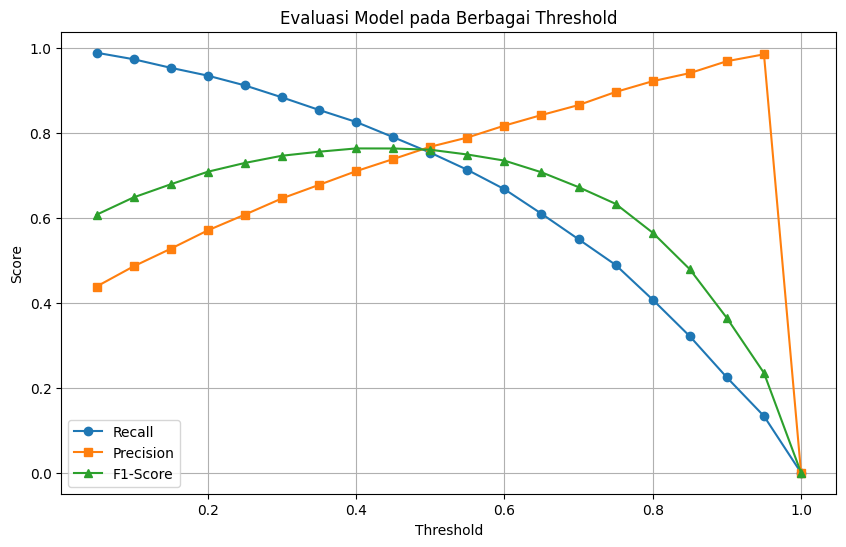

In [46]:
# Inisialisasi model XGBoost
model = XGBClassifier(random_state=42)
model.fit(X_train_under_tomek, y_train_under_tomek)

# Prediksi probabilitas
y_test_prob = model.predict_proba(X_test)[:, 1]

# Threshold yang diuji
thresholds = np.arange(0.05, 1.05, 0.05)
metrics = {
    "Threshold": [],
    "Recall": [],
    "Precision": [],
    "F1-Score": []
}

# Evaluasi pada berbagai threshold
for threshold in thresholds:
    y_test_pred = (y_test_prob >= threshold).astype(int)
    metrics["Threshold"].append(threshold)
    metrics["Recall"].append(recall_score(y_test, y_test_pred))
    metrics["Precision"].append(precision_score(y_test, y_test_pred))
    metrics["F1-Score"].append(f1_score(y_test, y_test_pred))

# Konversi ke DataFrame
metrics_df = pd.DataFrame(metrics)

# Plot hasil evaluasi
plt.figure(figsize=(10, 6))
plt.plot(metrics["Threshold"], metrics["Recall"], marker='o', label="Recall")
plt.plot(metrics["Threshold"], metrics["Precision"], marker='s', label="Precision")
plt.plot(metrics["Threshold"], metrics["F1-Score"], marker='^', label="F1-Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Evaluasi Model pada Berbagai Threshold")
plt.legend()
plt.grid()
plt.show()

In [47]:
metrics_df

,Threshold,Recall,Precision,F1-Score
0,0.05,0.989011,0.438376,0.607486
1,0.10,0.973693,0.485956,0.648337
2,0.15,0.953546,0.527348,0.679118
3,0.20,0.935065,0.570616,0.708733
4,0.25,0.912088,0.607721,0.729427
5,0.30,0.883949,0.645942,0.746432
6,0.35,0.854312,0.677807,0.755893
7,0.40,0.826007,0.710033,0.763642
8,0.45,0.790210,0.738562,0.763514
9,0.50,0.753746,0.767548,0.760585


###a. Pemilihan Threshold dalam Prediksi Pembatalan.


Dalam pemilihan model prediksi akurat dan seimbang, perlu diterapkan treshold terhadap model. Threshold diperlukan karena sebagian besar model klasifikasi (seperti Logistic Regression) menghasilkan probabilitas, bukan langsung label kelas. Agar probabilitas tersebut bisa diubah menjadi keputusan tegas (misalnya 0 = tidak batal, 1 = batal), kita membutuhkan batas pemisah yang disebut threshold.

Tanpa threshold, model tidak bisa menentukan kapan suatu probabilitas dianggap cukup kuat untuk masuk ke kelas positif. Selain itu, threshold memungkinkan kita menyesuaikan model dengan kebutuhan bisnis. Jika ingin mengurangi false negative, threshold bisa diturunkan (recall naik); jika ingin mengurangi false positive, threshold bisa dinaikkan (precision naik). Jadi, threshold memberi fleksibilitas untuk mengontrol trade-off antara precision dan recall sesuai konteks masalah.

###b. Threshold dengan F1-Score

Dalam permasalahan penyewaan kamar hotel, tujuan utama adalah meningkatkan jumlah nasabah yang tidak membatalkan pemesanan, dan menekan angka False Negative dan False Positive. Kehadiran angka False Negative dapat mengurangi kepercayaan konsumen terhadap pelayanan pihak hotel (Memesan ruang, tapi tidak terdaftar di database), dan kehadiran False Positive juga menyebabkan kerugian biaya dalam berjalannya suatu hotel (di database memesan ruang, tapi nyatanya tidak datang.) Oleh sebab itu, metrik Precision   dan F1-score menjadi sangat penting dalam menentukan threshold terbaik


Threshold 0.35
| Threshold | Recall   | Precision | F1-Score |
|-----------|---------|-----------|----------|
| 0.35      | 0.854312 | 0.676807  | 0.755893 |

Threshold 0.40
| Threshold | Recall   | Precision | F1-Score |
|-----------|---------|-----------|----------|
| 0.40      | 0.826007 | 0.710033 | 0.763642 |

Threshold 0.45
| Threshold | Recall   | Precision | F1-Score |
|-----------|---------|-----------|----------|
| 0.45      | 0.790210 | 0.738562  | 0.763514 |

Threshold 0.50
| Threshold | Recall   | Precision | F1-Score |
|-----------|---------|-----------|----------|
| 0.50      | 0.753746 | 0.767548  | 0.760585 |

Threshold yang dipilih dalam proyek ini harus memiliki keseimbangan antara F1-Score dan Precision. Data Threshold `0.35`, `0.40`, `0.45`, dan `0.55` menunjukkan nilai precision dan f1-Score yang tidak seimbang.

Threshold 0.50 dipilih karena memiliki f1-score yang hampir identik (dibutuhkan karena dalam proyek ini yang menjadi metric primer adalah f1-score) dibanding dengan Precision. Nilai precision di 0.50 juga cukup stabil di 76%. Oleh sebab itu, threshold 0.50 digunakan dalam proyek ini dalam penentuan skor F1-Score dan Precision.

###c. Kesimpulan Akhir (Mengapa Threshold=0.50)

Threshold **0.50 dipilih karena memberikan keseimbangan terbaik antara recall dan precision** dalam konteks prediksi pembatalan kamar. `F1 score` tinggi dalam konteks pembatalan kamar berarti model memiliki keseimbangan yang baik antara `precision` dan `recall`, artinya dari seluruh tamu yang diprediksi akan membatalkan reservasi, sebagian besar memang benar-benar batal `(false positive rendah)`, dan dari seluruh tamu yang benar-benar membatalkan, sebagian besar berhasil terdeteksi oleh model` (false negative rendah)`, sehingga model tidak terlalu sering salah menuduh tamu akan batal maupun terlalu sering melewatkan pembatalan yang sebenarnya, membuatnya cukup andal untuk mendukung keputusan bisnis seperti pengelolaan overbooking dan meminimalkan kerugian kamar kosong.

Threshold yang dipilih juga menunjukkan bahwa nilai `Precision` hampir mirip dengan `F1-score` jika precision = recall; dalam konteks pembatalan kamar, ini termasuk proporsi prediksi batal yang benar `(precision)` sama dengan proporsi pembatalan yang berhasil terdeteksi `(recall)`, sehingga model memiliki keseimbangan yang sangat konsisten antara tidak salah menuduh tamu batal dan tidak melewatkan tamu yang benar-benar batal.



#Feature Importance

In [48]:
# CELL 3 : Target and Features Separation
target_column = 'is_canceled'

# Perbaikan: Hapus 'is_canceled' dan 'reservation_status' (Data Leakage)
# Jangan masukkan 'target_column' dalam tanda kutip di dalam .drop()
X2 = df_prep.drop(columns=[target_column, 'reservation_status'])
y2 = df_prep[target_column]

In [49]:
# train dan test data ke Pipeline baru
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, random_state=0, stratify=y2)

In [50]:
# ColumnTransformer hanya mengembalikan X_transformed
X_train_transformed = transformer.fit_transform(X_train2, y_train2)

# Ambil nama fitur
feature_names = transformer.get_feature_names_out()
feature_names

array(['one_hot_encoder__hotel_City Hotel',
       'one_hot_encoder__hotel_Resort Hotel', 'one_hot_encoder__meal_BB',
       'one_hot_encoder__meal_FB', 'one_hot_encoder__meal_HB',
       'one_hot_encoder__meal_SC', 'one_hot_encoder__meal_Undefined',
       'one_hot_encoder__market_segment_Aviation',
       'one_hot_encoder__market_segment_Complementary',
       'one_hot_encoder__market_segment_Corporate',
       'one_hot_encoder__market_segment_Direct',
       'one_hot_encoder__market_segment_Groups',
       'one_hot_encoder__market_segment_Offline TA/TO',
       'one_hot_encoder__market_segment_Online TA',
       'one_hot_encoder__market_segment_Other',
       'one_hot_encoder__customer_type_Contract',
       'one_hot_encoder__customer_type_Group',
       'one_hot_encoder__customer_type_Transient',
       'one_hot_encoder__customer_type_Transient-Party',
       'one_hot_encoder__reserved_room_type_A',
       'one_hot_encoder__reserved_room_type_B',
       'one_hot_encoder__reserved_r

In [51]:
tomek = TomekLinks()
X_train_under_tomek, y_train_under_tomek = tomek.fit_resample(X_train_transformed, y_train2)

# Konverse ke Dataframe agar nama fitur tidak hilang
X_train_under_tomek = pd.DataFrame(X_train_under_tomek, columns=feature_names)

In [52]:
# Inisialisasi dan latih model XGBoost
model = XGBClassifier(random_state=42)
model.fit(X_train_under_tomek, y_train_under_tomek)

# Ambil feature importance dari model
feature_importance = model.feature_importances_

# Buat DataFrame untuk visualisasi
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

In [53]:
importance_df

,Feature,Importance
13,one_hot_encoder__market_segment_Online TA,0.147758
69,remainder__required_car_parking_spaces,0.117117
30,one_hot_encoder__deposit_type_Non Refund,0.075974
74,remainder__booking_complexity,0.060716
42,ordinal__country_grouped,0.043908
...,...,...
31,one_hot_encoder__deposit_type_Refundable,0.000000
14,one_hot_encoder__market_segment_Other,0.000000
16,one_hot_encoder__customer_type_Group,0.000000
27,one_hot_encoder__reserved_room_type_L,0.000000


/tmp/ipykernel_1462/629188832.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


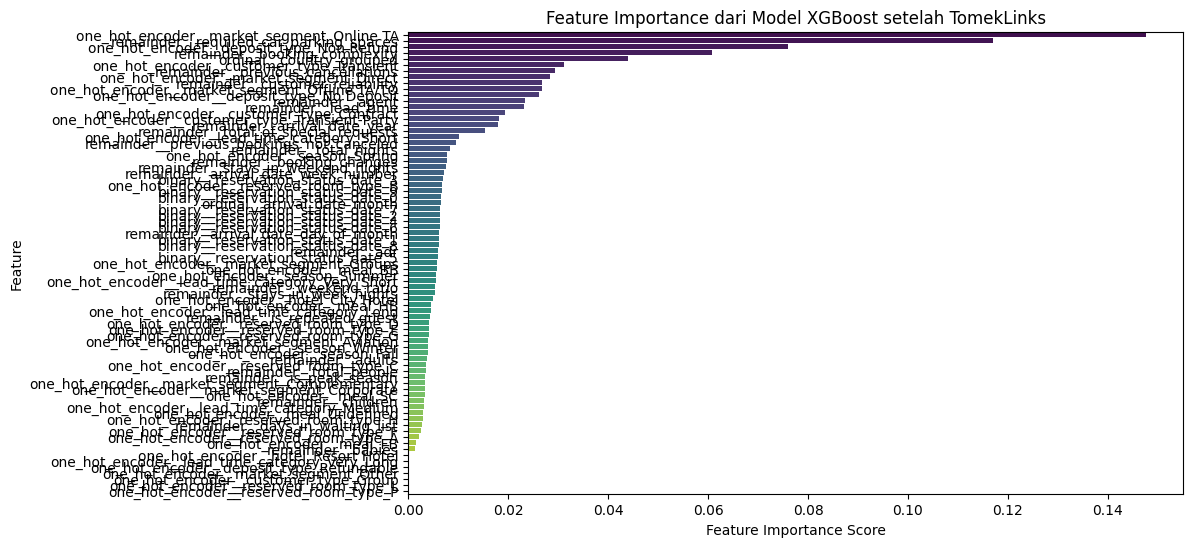

In [54]:
# Plot Feature Importance

plt.figure(figsize=(10, 6))

sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")

plt.xlabel("Feature Importance Score")

plt.ylabel("Feature")

plt.title("Feature Importance dari Model XGBoost setelah TomekLinks")

plt.show()



### a. **Kesimpulan dari Feature Importance XGBoost setelah One Side Selection**  

### **1. Analisis Feature Importance**  
- **Fitur "market_segment_Online_TA" memiliki pengaruh terbesar** terhadap prediksi model, dengan skor feature importance jauh lebih tinggi dibandingkan fitur lain.  
- **Fitur segmen pemasaran seperti "Online dan Offline TA" dan "Groups**, menunjukkan bahwa faktor bentuk pemasaran dan bagaimana pihak hotel menjual kamarnya untuk didistribusikan kepada pengunjung memegang kunci pembatalan / tidaknya pemesanan kamar.  
- **Beberapa fitur kategori seperti "room_type", "total_of_special_request", dan "customer_tpye" memiliki kontribusi menengah**, tetapi tidak sekuat fitur ekonomi makro, namun bila dipertimbangkan dapat membantu pertumbuhan bisnis hotel.   
- **Banyak fitur memiliki kontribusi yang sangat rendah**, terlihat dari skor yang mendekati dan mencapai nol.  

---

### **2. Alasan Hanya Ingin Melihat SHAP tanpa Feature Selection**  

**A. Memahami Dampak Fitur Secara Individu**  
- Feature Importance dari XGBoost hanya menunjukkan rata-rata pengaruh fitur terhadap model, bagaimana model menggunakan fitur paling banyak untuk menghasilkan prediksi, tetapi tidak memberikan pemahaman tentang **arah dampak (positif/negatif)** suatu fitur pada setiap prediksi individu.  
- **SHAP (SHapley Additive Explanations) lebih detail**, karena menunjukkan **bagaimana setiap fitur mempengaruhi keputusan model** secara lokal dan global.  

**B. Menghindari Kehilangan Informasi Penting**  
- Feature selection bisa saja menghapus fitur yang tampak kurang penting secara global, tetapi tetap relevan dalam kombinasi dengan fitur lain.  
- Dengan **SHAP**, kita bisa melihat apakah ada fitur yang tampaknya tidak penting, tetapi memiliki dampak besar dalam kasus-kasus tertentu.  

**C. Mengevaluasi Interaksi Antar Fitur**  
- SHAP dapat membantu memahami **bagaimana fitur berinteraksi** satu sama lain, misalnya apakah "country_grouped" dan "reserved_room_type" memiliki efek yang lebih kuat jika dikombinasikan.  
- Feature selection bisa menghilangkan fitur tanpa mempertimbangkan interaksi ini.  

**D. Interpretasi Model yang Lebih Transparan**  
- Jika tujuan utama adalah **memahami model secara mendalam (interpretability) daripada hanya meningkatkan performa**, maka **SHAP lebih informatif** dibandingkan sekadar melakukan feature selection.  
- Tim Perhotelan atau tim bisnis mungkin memerlukan alasan mengapa model memprediksi seorang akan membatalkan pemesanan ruang atau tidak. SHAP akan memberi insight lebih mendalam mengenai hal ini.

---

### **3. Kesimpulan**  
**Alih-alih melakukan feature selection yang bisa menghapus fitur tanpa mempertimbangkan dampaknya dalam kombinasi dengan fitur lain, lebih baik menggunakan SHAP untuk mendapatkan wawasan yang lebih dalam tentang dampak setiap fitur terhadap keputusan model.**


###b. SHAP

100%|===================| 60932/61102 [05:25<00:00]       

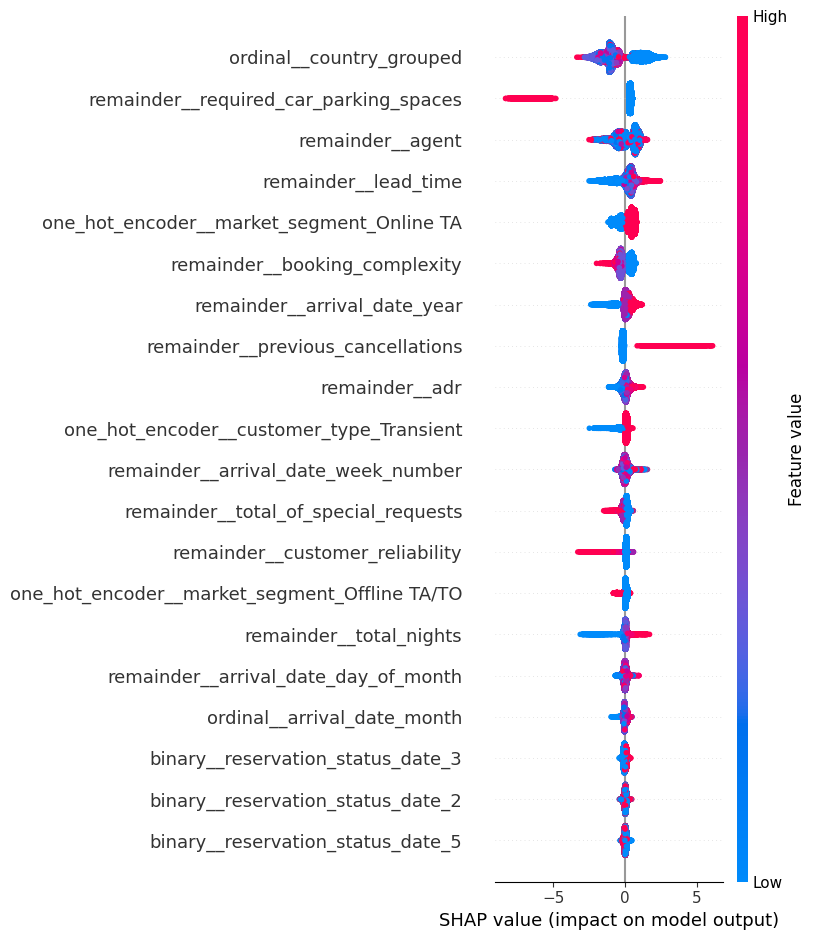

In [55]:
import shap
import matplotlib.pyplot as plt

# Buat explainer SHAP
explainer = shap.Explainer(model, X_train_under_tomek)
shap_values = explainer(X_train_under_tomek)

# Summary Plot (SHAP Global Feature Importance)
shap.summary_plot(shap_values, X_train_under_tomek)

**Overview**

**Cara Membaca SHAP Value**
Sumbu X (SHAP Value): Menunjukkan dampak fitur terhadap output model. Jika titik berada di sebelah kanan (positif), fitur tersebut mendorong model untuk memprediksi pembatalan (1). Jika di kiri (negatif), fitur mendorong prediksi tidak batal (0).  

Warna (Feature Value): Merah menunjukkan nilai fitur yang tinggi, sedangkan biru menunjukkan nilai fitur yang rendah.  

Analisis Fitur Utama (Top 5)
`country_grouped` (Ordinal)

Fitur ini menempati posisi teratas dalam memengaruhi model.  

Titik-titik merah di sisi kanan menunjukkan bahwa asal negara tertentu memiliki kecenderungan pembatalan yang sangat kuat. Berdasarkan data, tamu mancanegara seringkali memiliki pola pembatalan yang berbeda dibanding tamu lokal (Portugal).  

`required_car_parking_spaces`

Terdapat garis merah tebal di sisi kiri (negatif). Artinya, tamu yang memesan slot parkir hampir pasti tidak akan membatalkan pesanannya.  

Ini adalah prediktor stabilitas yang sangat kuat bagi hotel.  

`agent`

Keterlibatan agen perjalanan tertentu (titik merah di kanan) meningkatkan kemungkinan pembatalan.  

Sebaliknya, pemesanan tanpa agen atau melalui agen tertentu (titik biru) cenderung lebih stabil.  

`lead_time`

Titik merah berada di sisi kanan. Ini membuktikan asumsi bahwa semakin lama jarak antara waktu pemesanan dan waktu kedatangan (lead time tinggi), semakin tinggi pula risiko tamu tersebut akan membatalkan reservasi karena perubahan rencana di masa depan.  

`market_segment_Online TA`

Pemesanan melalui Online Travel Agent (warna merah di kanan) berkontribusi signifikan terhadap angka pembatalan.  

Hal ini konsisten dengan kemudahan kebijakan pembatalan yang sering ditawarkan oleh platform online.  

Insight Penting Lainnya
`previous_cancellations`: Garis merah panjang di sisi kanan menunjukkan bahwa tamu yang memiliki riwayat pernah membatalkan pesanan di masa lalu sangat cenderung untuk membatalkan kembali pesanannya saat ini (behavioral pattern).  

`total_nights`: Tamu dengan durasi menginap yang lebih lama (merah) cenderung memiliki dampak positif terhadap pembatalan di beberapa kasus, namun ada juga titik biru di kiri yang menunjukkan menginap sebentar (weekend stay) seringkali lebih pasti datang.  

`customer_reliability`: Fitur ini menunjukkan bahwa tamu dengan tingkat reliabilitas rendah (warna merah di kiri SHAP) sebenarnya membantu model mengidentifikasi mereka yang tidak akan batal, yang berkaitan dengan riwayat transaksi sukses mereka sebelumnya.  

Kesimpulan Strategis
Model kamu menunjukkan bahwa logistik (parkir), riwayat perilaku (cancel sebelumnya), dan sumber pemesanan (Online TA) adalah kunci utama. Tim Marketing bisa memberikan perhatian khusus atau kebijakan deposit yang lebih ketat pada pemesanan dengan lead time panjang atau dari segmen Online TA untuk menekan angka pembatalan sebesar 37.05% tersebut

###c.  Resampling dan Model Terbaik

Berdasarkan eksperimen _trial and error_ yang dilakukan, ditemukan bahwa metode resampling TomekLinks sebagai teknik undersampling dengan XGBoost (tanpa hyperparameter tuning) menghasilkan model dengan nilai F1-score yang baik serta nilai precision yang seimbang dengan F1-score juga.

Berikut penjelasan rinci bagaimana One Sided Selection bekerja bersama dengan model XGBoost dalam menentukan model terbaik dalam proyek ini.

1. **TomekLinks: Teknik Undersampling dengan membersihkan decision boundary**

Tomek Links adalah teknik undersampling dalam pengolahan data tidak seimbang yang bertujuan untuk membersihkan batas keputusan (decision boundary) antar kelas dengan cara menghapus data yang dianggap sebagai noise atau tumpang tindih. Metode ini bekerja dengan mencari pasangan data terdekat ( nearest neighbor) dari kelas yang berbeda, di mana jika keduanya saling menjadi tetangga terdekat, maka pasangan tersebut disebut sebagai Tomek Link. Dalam prosesnya, biasanya titik dari kelas mayoritas dalam pasangan tersebut akan dihapus untuk mempertegas pemisahan antar kelas, sehingga algoritma klasifikasi dapat menentukan batas yang lebih jelas dan meningkatkan performa model dalam mengenali kelas minoritas.

2. **XGBoost: Model Algoritma Booosting untuk Meningkatkan Kerja Model**

XGBoost (Extreme Gradient Boosting) adalah algoritma berbasis pohon keputusan yang menggunakan pendekatan boosting untuk meningkatkan akurasi prediksi. Model ini digunakan dengan konsiderasi banyaknya data kategori dalam dataframe yang digunakan.

3. **Kombinasi OSS dengan XGBoost**

Kombinasi XGBoost dengan One-Sided Selection (OSS) digunakan untuk menangani ketidakseimbangan kelas sebelum proses boosting dilakukan. OSS menyeleksi data mayoritas yang benar-benar penting sehingga XGBoost dapat membangun decision boundary yang lebih akurat.

- OSS sebagai tahap praproses data
OSS mengurangi sampel kelas mayoritas secara selektif dengan mempertahankan titik-titik yang dekat dengan kelas minoritas (boundary), sehingga distribusi data menjadi lebih seimbang tanpa menghilangkan informasi penting.

- XGBoost sebagai model klasifikasi utama
Setelah data dibersihkan oleh OSS, XGBoost melatih model boosting pada dataset yang lebih representatif, sehingga bias terhadap kelas mayoritas berkurang dan performa metrik seperti recall dan F1-score pada kelas minoritas cenderung meningkat.


Kombinasi antara XGBoost dan Tomek Links merupakan pendekatan yang sangat efektif untuk menangani masalah klasifikasi pada dataset yang tidak seimbang (imbalanced dataset), seperti pada studi kasus pembatalan reservasi hotel kamu. Strategi ini menggabungkan kekuatan algoritma boosting yang tangguh dengan teknik pembersihan data berbasis geometri.  

Berikut adalah penjelasan cara kerja kombinasi tersebut:

1. Pembersihan Data dengan Tomek LinksLangkah pertama dilakukan pada tahap preprocessing. Tomek Links bekerja dengan mengidentifikasi pasangan data dari kelas yang berbeda (misalnya: satu reservasi "batal" dan satu "datang") yang posisinya sangat berdekatan dan saling menjadi tetangga terdekat.  Menghapus Noise: Titik dari kelas mayoritas (tamu yang datang) yang masuk ke area kelas minoritas akan dihapus.  Mempertegas Batas: Proses ini menciptakan "ruang kosong" atau batas yang lebih jelas (clearer decision boundary) antar kelas, sehingga model tidak bingung saat menghadapi data yang tumpang tindih.  
2. Klasifikasi dengan XGBoostSetelah data dibersihkan oleh Tomek Links, dataset yang sekarang lebih "rapi" dimasukkan ke dalam algoritma XGBoost.  Fokus pada Pola Esensial: Karena noise di perbatasan sudah berkurang, XGBoost dapat lebih fokus mempelajari fitur-fitur penting seperti lead_time, country_grouped, dan required_car_parking_spaces tanpa terganggu oleh data anomali.  

Optimasi Gradient: XGBoost akan membangun pohon keputusan secara bertahap untuk meminimalkan kesalahan, yang dalam kasus ini akan jauh lebih efisien karena pemisahan kelas sudah dipertajam oleh Tomek Links sebelumnya.  Manfaat Utama bagi Model KamuMeningkatkan Precision dan F1-Score: Seperti yang kamu inginkan untuk menekan False Positive dan False Negative, pembersihan batas kelas sangat membantu model agar lebih akurat dalam menentukan apakah seorang tamu benar-benar akan batal atau tidak.  

Mengurangi Bias Mayoritas: Dengan menghapus elemen mayoritas yang ambigu, model tidak akan secara membabi buta memprediksi semua tamu akan "datang" hanya karena kelas tersebut lebih dominan di dataset awal.  Dalam alur kerja kamu, pastikan Tomek Links dijalankan setelah tahap transformasi data (seperti One-Hot Encoding atau Binary Encoding) karena algoritma ini membutuhkan perhitungan jarak matematis yang hanya bisa dilakukan pada angka.

###d. Confusion matrix

In [56]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, random_state=0, stratify=y2) # tran dan test data ke Pipeline baru

In [57]:
pd.DataFrame(X_test2).to_csv('X_test2.csv', index=False) # Mengambil CSV Test untuk Pengujian di deploy Machine Learning

In [58]:
from imblearn.pipeline import Pipeline

# Buat pipeline yang mencakup transformer dan model
best_model = Pipeline([
    ('transformer', transformer),  # Transformasi awal
    ('Tomeklinks', TomekLinks()),  # Resampling Tomeklinks
    ('model', XGBClassifier(random_state=67)) # Model XGBoost
])

# Latih model
best_model.fit(X_train2, y_train2)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['hotel', 'meal',
                                                   'market_segment',
                                                   'customer_type',
                                                   'reserved_room_type',
                                                   'deposit_type', 'season',
                                                   'lead_time_category']),
                                                 ('ordinal',
                                                  OrdinalEncoder(mapping=[{'col': 'arrival_date_month',
                                                                           'data_type': dtype('O'),
                                                                           'm...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [59]:
# Prediksi probabilitas menggunakan predict_proba
y_prob = best_model.predict_proba(X_test2)[:, 1]  # Ambil probabilitas kelas 1 (positif)

threshold = 0.50

In [60]:
# Terapkan threshold untuk menghasilkan prediksi kelas (0 atau 1)
y_pred = (y_prob >= threshold).astype(int)

In [61]:
# y_pred = best_model_exc.predict(X_test)
print(classification_report(y_test2, y_pred))
print(f'F1 Score: {f1_score(y_test2, y_pred)}')

              precision    recall  f1-score   support

           0       0.91      0.91      0.91     15843
           1       0.77      0.75      0.76      6006

    accuracy                           0.87     21849
   macro avg       0.84      0.83      0.84     21849
weighted avg       0.87      0.87      0.87     21849

F1 Score: 0.7605846774193549


<Axes: >

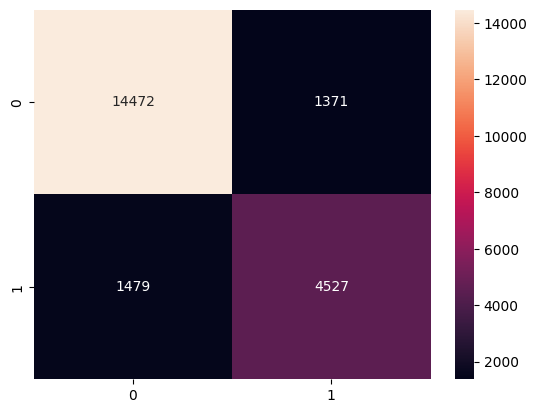

In [62]:
confusion_matrix(y_test2,y_pred)

sns.heatmap(confusion_matrix(y_test2,y_pred), annot = True, fmt='d')

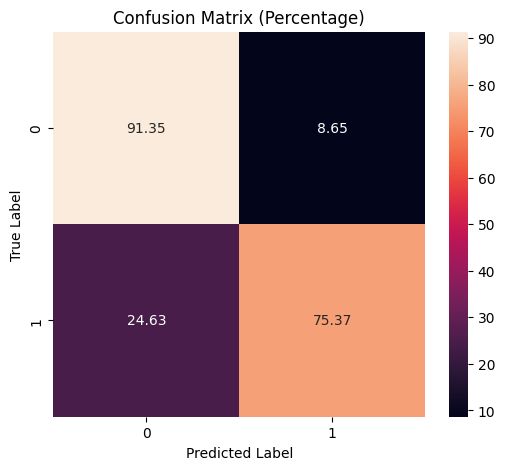

In [63]:
# Hitung Confusion Matrix
conf_matrix = confusion_matrix(y_test2, y_pred)

# Konversi ke Persentase (%)
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix_percent, annot=True, fmt=".2f", cbar=True)

# Label sumbu
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()

#Data Limitation

**Rentang Data yang Berlaku untuk Model Ini**

Model ini hanya berlaku pada rentang data yang digunakan dalam pemodelan ini, yaitu:


**Variable**
1. `hotel`:	Hotel (H1 = Resort Hotel or H2 = City Hotel)
2. `is_canceled`:	Value indicating if the booking was canceled (1) or not (0)
3. `lead_time`:	Number of days that elapsed between the entering date of the booking into the PMS and the arrival date
4. `arrival_date_year`:	Year of arrival date
5. `arrival_date_month`:	Month of arrival date
6. `arrival_date_week_number`:	Week number of year for arrival date
7. `arrival_date_day_of_month`:	Day of arrival date
8. `stays_in_weekend_nights`:	Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
9. `stays_in_week_nights`:	Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
10. `adults`:	Number of adults
11. `children`:	Number of children
12. `babies`:	Number of babies
13. `meal`:	Type of meal booked. Categories are presented in standard hospitality meal packages: Undefined/SC – no meal
14. `country`: 	Country of origin. Categories are represented in the ISO 3155–3:2013 format
15. `market_segment`:	Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour
16. `distribution_channel`:	"Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”
17. `is_repeated_guest`:	Value indicating if the booking name was from a repeated guest (1) or not (0)
18. `previous_cancellations`:	Number of previous bookings that were cancelled by the customer prior to the current booking
19. `previous_bookings_not_canceled`:	Number of previous bookings not cancelled by the customer prior to the current booking
20. `reserved_room_type`:	Code of room type reserved. Code is presented instead of designation for anonymity reasons.
21. `assigned_room_type`:	Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved
22. `booking_changes`:	Number of changes/amendments made to the booking from the moment the booking was entered on
23. `deposit_type`:	Indication on if the customer made a deposit to guarantee the booking. This variable can assume three
24. `agent`:	ID of the travel agency that made the booking
25. `company`:	ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of
26. `days_in_waiting_list`:	Number of days the booking was in the waiting list before it was confirmed to the customer
27. `customer_type`:	Type of booking, assuming one of four categories: Contract - when the booking has an allotment or other type of contract associated to it;
28. `adr`:	Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights
required_car_parking_spaces	Number of car parking spaces required by the customer
29. `total_of_special_requests`:	Number of special requests made by the customer (e.g. twin bed or high floor)
30. `reservation_status`:	Reservation last status, assuming one of three categories: Canceled – booking was canceled by the customer; Check-Out
31. `reservation_status_date`:	Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to



#Save Model

In [65]:
import pickle

# Pastikan model_data berbentuk dictionary
model_dict = {
    "model": best_model,  # Pipeline yang isinya transformer, nearmiss, model
    "threshold": 0.45         # Threshold yang ditentukan mandiri
}

# Simpan ulang dengan format dictionary
with open("best_model_hotel_prediction.pkl", "wb") as file: # Menyimpan model untuk deploy
    pickle.dump(model_dict, file)

print("Model disimpan dengan format dictionary!")

Model disimpan dengan format dictionary!


#Business Impact

####a. Tanpa Menggunakan Machine Learning:
Berdasarkan data:
- Total pengunjung = 87.396

- Cancelation rate = 37%

- Jumlah pengunjung yang datang: 87.396 × (1 − 0,37) = 55.060

Perhitungan Biaya

- Total Biaya Operasional = 55.060 × 186 = 10.241.160 euro [mempersiapkan seluruh kamar]

Perhitungan Pendapatan

- Rata-rata harga kamar = 300 euro
- Pendapatan Hotel = 55.060 × 300 = 16.518.000 euro
- Perhitungan Profit
- Net Profit = 16.518.000  − 10.241.160 = 6.276.840 euro
- Margin = 6.276.840 ÷ 16.518.000 ≈ 32%

Jadi untuk skenario harga kamar 300 euro dan cancelation 37%, profit margin yang didapat hotel hanya 32%

####b. Dengan Menggunakan Machine Learning:

**Confusion Matrix:**
- True Positive (TP) = 54.996
- False Positve (FP) = 4.757
- True Negative (TN) = 7.955
- False Negative (FN) = 24.345

Berdasarkan data:
- Total kamar yang disiapkan (berdasarkan prediksi) = TP + FP = 54.996 + 4.757= 59.753
- Jumlah pengunjung yang benar-benar datang = TP = 54.996

Perhitungan Biaya
- Total Biaya Operasional = 59.753 × 186 ≈ 11.114.058 euro

Perhitungan Pendapatan
- Rata-rata harga kamar = 300 euro
- Pendapatan Hotel = 54.996 × 300 ≈ 16.498.800 euro
Perhitungan Profit

- Net Profit = 16.498.800  − 11.114.058 ≈ 5.534.742 euro
- Margin = 5.534.742 ÷ 16.498.800  ≈ 34,4%

###c. Kesimpulan Profit Margin

Dari hasil perhitungan, dapat disimpulkan bahwa penggunaan machine learning dapat membantu pihak hotel untuk mmepersiapkan biaya secara efektif untuk mencegah kerugian tinggi akibat mempersiapkan seluruh kamar. Metode machine learning F1-score dapat menaikkan cost to profit margin dari `32%` menjadi `34,4%`. Machine learning membantu hotel dalam memprediksi pengunjung yang datang, sehingga hotel dapat mempersiapkan diri, mengeluarkan uang sesuai dengan pengunjung yang datang, berbeda dengan hasil tanpa machine learning, dimana pihak hotel melakukan overspending untuk mengantisipasi pengunjung yang membludak.

Dengan machine learning, perusahaan dapat dengan bijak menata keuangannya untuk mempersiapkan diri terhadap pelanggan yang membatalkan dan pelanggan yang datang. Dengan memprediksi aktivitas dengan tepat, kepercayaan pelanggan terhadap pihak perhotelan dapat menaik juga


#Rekomendasi

####a. Market Segment

-  Segmentasi pasar berdasarkan sumber pemesanan kamar menjadi faktor penting dalam menentukan tingkat penyewaan maupun pembatalan kamar. Setiap segmen memiliki karakteristik perilaku yang berbeda, sehingga strategi yang diterapkan juga perlu disesuaikan.

-  Prioritaskan segmen Online TA karena segmen ini memiliki jumlah pengunjung paling besar. Dengan memberikan promo yang lebih terarah, kebijakan pembatalan yang lebih terkontrol, serta tambahan fasilitas khusus untuk pemesanan melalui Online TA, potensi pembatalan dapat ditekan tanpa mengurangi daya tarik pasar utama.

####b. Previous Cancellation

-  Perlu dilakukan tindakan preventif untuk menekan angka pembatalan berulang. Riwayat pembatalan yang tinggi menunjukkan tingkat komitmen pelanggan yang rendah, sehingga hotel dapat menerapkan kebijakan seperti deposit, reminder otomatis, atau penawaran khusus non-refundable untuk pelanggan dengan riwayat tersebut agar risiko kerugian dapat diminimalkan.

####c. Facilities

-  Ketersediaan fasilitas yang relevan dan mendukung kebutuhan tamu menjadi salah satu faktor utama dalam mengurangi pembatalan. Hotel dapat mempertimbangkan penambahan fasilitas yang bersifat low maintenance namun bernilai guna tinggi, sehingga tetap efisien secara biaya operasional tetapi mampu meningkatkan kepuasan dan keyakinan tamu untuk tetap menginap.

####d. Customer Type

- Memberikan lebih banyak promo, benefit loyalitas, dan fasilitas tambahan kepada customer tipe Groups dapat menjadi strategi efektif, mengingat segmen ini cenderung lebih stabil dan loyal.

- Untuk customer type kontrak yang memiliki potensi pembatalan lebih tinggi, perlu dilakukan evaluasi kebijakan kerja sama, seperti peninjauan ulang syarat kontrak, sistem penalti pembatalan, atau negosiasi ulang skema pembayaran agar risiko pembatalan dapat ditekan.

#Kesimpulan Akhir

Rekomendasi ini dilakukan untuk memperkaya fitur, memperjelas hubungan antar fitur agar model dapat mempelajari hubungan antar fitur untuk menciptakan model yang jauh lebih akurat dalam memprediksi pembatalan ruang di Hotel Lonestar Oriental